# Mobility & Infrastructure EDA

## Importing Libraries & Dataset

In [45]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [46]:
# mobility & infrastructure data
df_mi_raw = pd.read_csv("/Users/shaabanlaila/Desktop/summer26-sustainability-of-us-cities/data/CountyHealthRankings/CountyHealth_NC_Merged.csv")
df_mi = df_mi_raw[['state','county','Long_Commute_Driving_Alone_Raw', 'Broadband_Access_Raw','popdensity2010','mean_commutetime2000']]
print(df_mi.shape)
df_mi.head()

(74044, 6)


,state,county,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000
0,1,1,0.421,0.908804,504.75183,26.171911
1,1,1,0.421,0.908804,1682.17050,24.806705
2,1,1,0.421,0.908804,1633.41390,25.322525
3,1,1,0.421,0.908804,1780.03250,22.965347
4,1,1,0.421,0.908804,2446.26220,26.222353


74044 rows & 4 columns in dataset

### Columns:

**Long Commute Driving Alone Raw Value:** Among workers who commute in their car alone, the percentage that commute more than 30 minutes

**Broadband Access Raw Value:** Percentage of households with broadband internet connection

**Population Density:** Population density of census tract (neighborhood/area) in 2010

**Mean Commute Time:** Average number of minutes people in that census tract spent traveling from home to work in 2000

In [47]:
# making it county level
df_mi = df_mi.groupby(['state', 'county'], as_index=False).agg({
    'Long_Commute_Driving_Alone_Raw': 'first',
    'Broadband_Access_Raw': 'first',
    'popdensity2010': 'mean',
    'mean_commutetime2000': 'mean'
})

In [48]:
df_mi.info()
df_mi.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3223 entries, 0 to 3222
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   state                           3223 non-null   int64  
 1   county                          3223 non-null   int64  
 2   Long_Commute_Driving_Alone_Raw  3133 non-null   float64
 3   Broadband_Access_Raw            3133 non-null   float64
 4   popdensity2010                  3219 non-null   float64
 5   mean_commutetime2000            3142 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 151.2 KB


,state,county,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000
count,3223.000000,3223.000000,3133.000000,3133.000000,3219.000000,3142.000000
mean,31.292274,103.104871,0.332126,0.843286,919.352710,24.481882
std,16.283574,106.931484,0.127730,0.065744,2702.588854,5.590578
min,1.000000,1.000000,0.000000,0.481383,0.038679,7.166065
25%,19.000000,35.000000,0.238000,0.810151,44.610189,20.462973
50%,30.000000,79.000000,0.326000,0.852579,215.983778,23.961779
75%,46.000000,133.000000,0.419000,0.888158,1015.578023,27.941855
max,72.000000,840.000000,0.745000,1.000000,85269.315712,45.491780


* All variables are numeric.

* Some missing values are present: **90** missing in `Long_Commute_Driving_Alone_Raw` and `Broadband_Access_Raw`, **4** missing in `popdensity2010`, and **81** missing in `mean_commutetime2000`.

* The average county had a long driving commute-alone rate of **33.2%**, broadband access of **84.3%**, a 2010 population density of about **919**, and an average commute time of about **24.5 minutes** in 2000.

* Population density still appears highly right-skewed, since the mean is much larger than the median and the maximum is extremely high.

## Visualizations

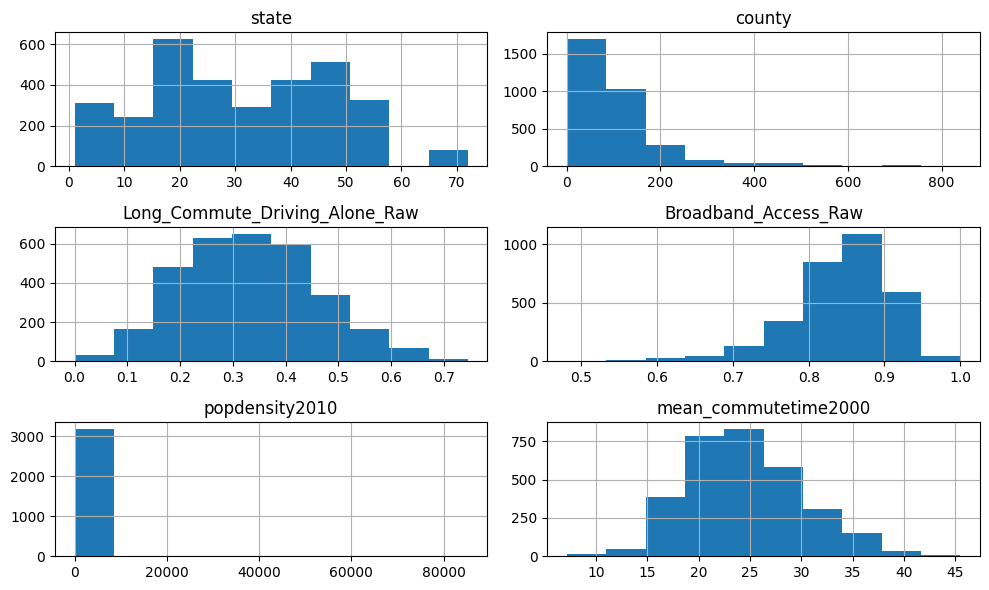

In [49]:
# histograms
df_mi.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

- **Long commute driving alone** appears fairly balanced, though slightly concentrated in the lower-to-middle range.

- **Broadband access** is left-skewed, with most counties having relatively high broadband access around **0.80–0.90**, and fewer counties having much lower access.

- **Population density in 2010** is extremely right-skewed. Most counties have low to moderate density, while a small number of very dense counties create high-end outliers.

- **Mean commute time in 2000** is slightly right-skewed, with most counties around **20–30 minutes** and a few counties reaching above **40 minutes**.

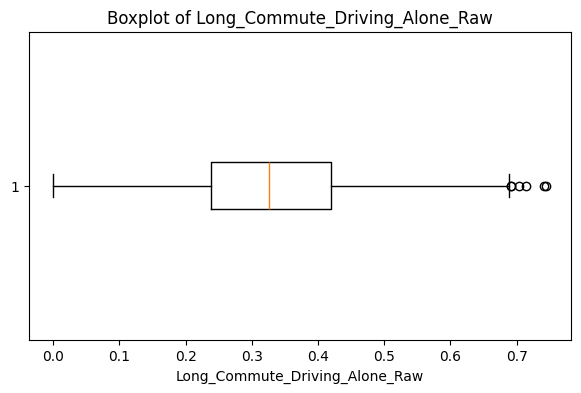

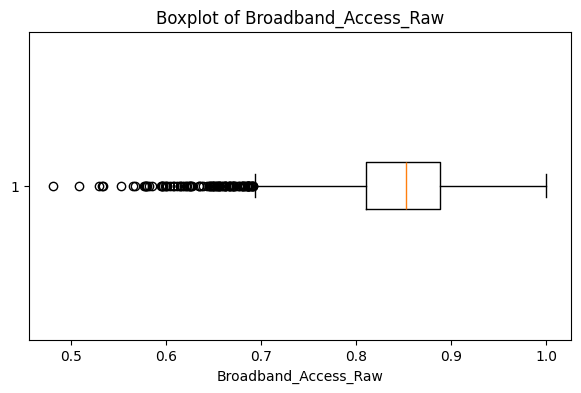

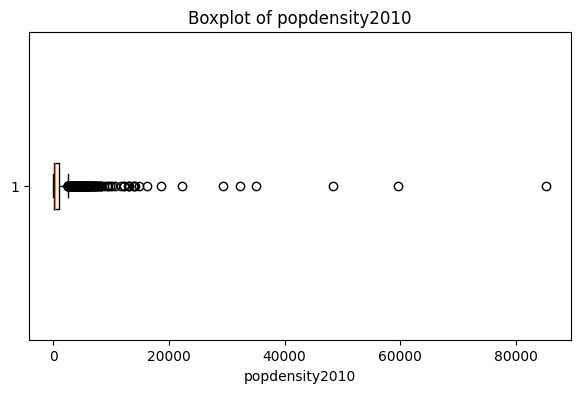

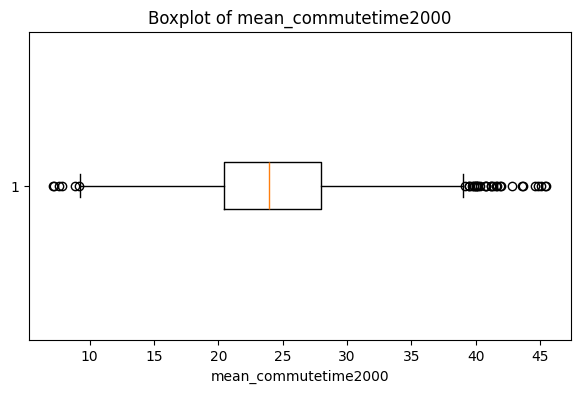

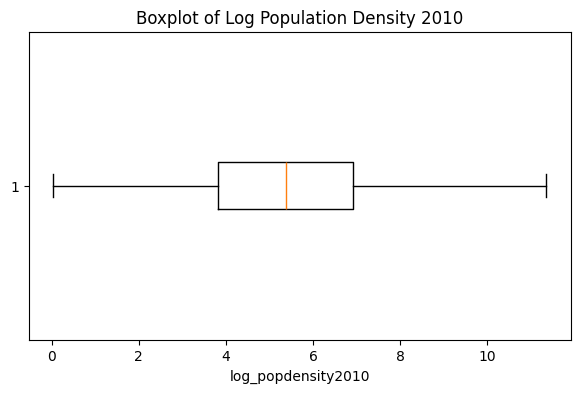

In [50]:
# boxplots
eda_cols = [
    'Long_Commute_Driving_Alone_Raw',
    'Broadband_Access_Raw',
    'popdensity2010',
    'mean_commutetime2000'
]

for col in eda_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df_mi[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

df_mi['log_popdensity2010'] = np.log1p(df_mi['popdensity2010']) # flattening population density's skew

plt.figure(figsize=(7, 4))
plt.boxplot(df_mi['log_popdensity2010'].dropna(), vert=False)
plt.title("Boxplot of Log Population Density 2010")
plt.xlabel("log_popdensity2010")
plt.show()

- **Long commute driving alone** is fairly balanced, with a few high outliers.

- **Broadband access** is left-skewed; most counties have high access, but some have much lower access.

- **Population density 2010** is extremely right-skewed, with several high-density outliers.

- **Mean commute time 2000** is slightly right-skewed; most counties are around 20–30 minutes, with some longer-commute outliers.

- **Log population density 2010** is much less skewed after logging, making it easier to interpret.

In [53]:
# checking correlation between variables
df_mi.corr()

,state,county,Long_Commute_Driving_Alone_Raw,Broadband_Access_Raw,popdensity2010,mean_commutetime2000,log_popdensity2010
state,1.000000,0.136293,0.010568,0.035952,0.049013,-0.001539,0.085752
county,0.136293,1.000000,-0.011882,-0.032632,0.001377,-0.016990,0.019260
Long_Commute_Driving_Alone_Raw,0.010568,-0.011882,1.000000,-0.073766,0.056759,0.867940,-0.030138
Broadband_Access_Raw,0.035952,-0.032632,-0.073766,1.000000,0.224471,-0.055340,0.444839
popdensity2010,0.049013,0.001377,0.056759,0.224471,1.000000,0.117027,0.456810
mean_commutetime2000,-0.001539,-0.016990,0.867940,-0.055340,0.117027,1.000000,0.084736
log_popdensity2010,0.085752,0.019260,-0.030138,0.444839,0.456810,0.084736,1.000000


- **Long commute driving alone** and **mean commute time 2000** have a very strong positive correlation of **0.868**, meaning counties with longer average commute times also tend to have higher long-commute driving-alone rates.

- **Broadband access** and **log population density 2010** have a moderate positive correlation of **0.445**, suggesting denser counties tend to have higher broadband access.

- **Population density 2010** and **log population density 2010** are moderately correlated at **0.457**, which is expected since the log variable is a transformed version of population density.

- Most other correlations are weak, suggesting limited linear relationships between the remaining variables.

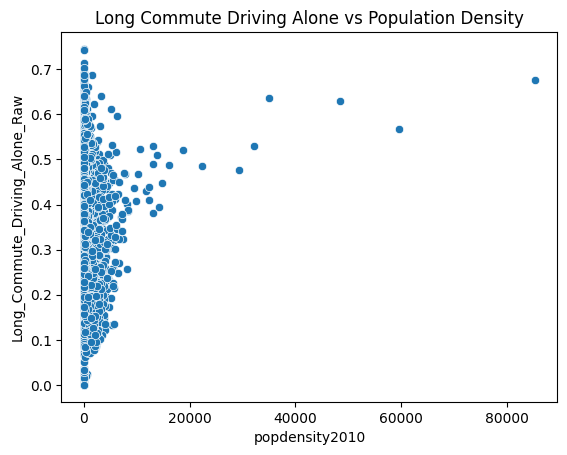

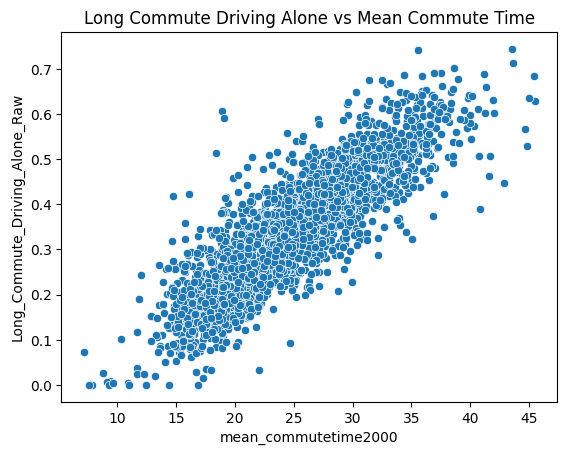

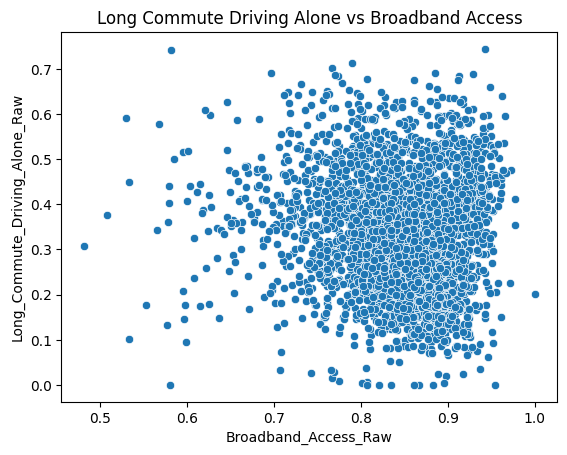

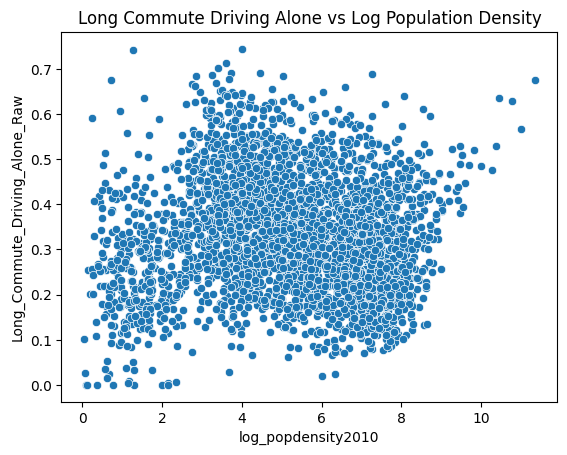

In [52]:
# scatterplots
sns.scatterplot(
    data=df_mi,
    x='popdensity2010',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Population Density")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='mean_commutetime2000',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Mean Commute Time")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='Broadband_Access_Raw',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Broadband Access")
plt.show()

sns.scatterplot(
    data=df_mi,
    x='log_popdensity2010',
    y='Long_Commute_Driving_Alone_Raw'
)
plt.title("Long Commute Driving Alone vs Log Population Density")
plt.show()

- **Long commute driving alone vs. population density:** Shows a weak linear relationship, with most counties clustered at low population densities.

- **Long commute driving alone vs. mean commute time:** Shows a strong positive linear relationship, meaning counties with longer average commute times tend to have higher long-commute driving-alone rates.

- **Long commute driving alone vs. broadband access:** Shows little to no clear linear relationship.

- **Long commute driving alone vs. log population density:** Still shows a weak relationship, but the log transformation makes the population density pattern easier to see.

## Conclusions

- Most variables are numeric and mostly complete, with only a small amount of missing data.

- Broadband access is generally high across counties, while long commute driving alone and commute time vary more across areas.

- Population density is highly right-skewed due to a small number of very dense counties, so a log transformation was used to make it easier to interpret.

- Correlation analysis showed a strong positive relationship between long commute driving alone and mean commute time, suggesting these variables capture similar commuting patterns.